## Modellering af epidemier

In [22]:
import matplotlib.pyplot as plt


class Population:
    def __init__(self, S, I):
        self.S = S
        self.I = I

    def total(self):
        return self.S + self.I


class Model:
    def __init__(self, smitteRate):
        self.smitteRate = smitteRate

    def step(self, population):
        N = population.total()

        dS = -self.smitteRate * population.S * population.I / N
        dI = self.smitteRate * population.S * population.I / N

        population.S += dS
        population.I += dI

        return population


class Simulering:
    def __init__(self, model, population):
        self.model = model
        self.population = population
        self.historik = []

    def simuler(self, steps):
        for _ in range(steps):
            self.historik.append((self.population.S, self.population.I))
            self.model.step(self.population)
        return self.historik


class Plotter:
    def __init__(self, historik):
        self.historik = historik

    def plot(self):
        S = []
        I = []
        for h in self.historik:
            S.append(h[0])
            I.append(h[1])

        plt.figure(figsize=(10, 6))
        plt.plot(S, label='S - smittelige', color='blue')
        plt.plot(I, label='I - inficerede', color='darkred')
        plt.xlabel('Tid')
        plt.ylabel('Antal personer')
        plt.title('SI-model')
        plt.legend()
        plt.grid(True)
        plt.show()


### Opgave med SI-modellen

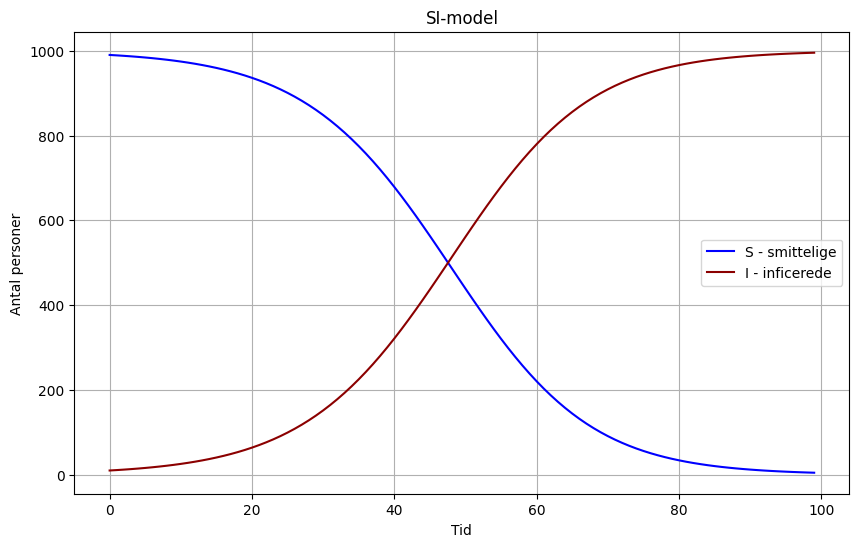

In [23]:
population = Population(S=990, I=10)
model = Model(smitteRate=0.1)
simulering = Simulering(model, population)

historik = simulering.simuler(steps=100)
Plotter(historik).plot()

### Opgave fra SI- til SIR-model

In [50]:
import matplotlib.pyplot as plt


class Population:
    def __init__(self, S, I, R):
        self.S = S
        self.I = I
        self.R = R

    def total(self):
        return self.S + self.I


class Model:
    def __init__(self, smitteRate, raskRate):
        self.smitteRate = smitteRate
        self.raskRate = raskRate

    def step(self, population):
        N = population.total()

        dS = -self.smitteRate * population.S * population.I / N
        dI = self.smitteRate * population.S * population.I / N
        dR = self.raskRate * population.I

        population.S += dS
        population.I += dI-dR
        population.R += dR
        

        return population


class Simulering:
    def __init__(self, model, population):
        self.model = model
        self.population = population
        self.historik = []

    def simuler(self, steps):
        for _ in range(steps):
            self.historik.append((self.population.S, self.population.I, self.population.R))
            self.model.step(self.population)
        return self.historik


class Plotter:
    def __init__(self, historik):
        self.historik = historik

    def plot(self):
        S = []
        I = []
        R = []
        for h in self.historik:
            S.append(h[0])
            I.append(h[1])
            R.append(h[2])

        plt.figure(figsize=(10, 6))
        plt.plot(S, label='S - smittelige', color='blue')
        plt.plot(I, label='I - inficerede', color='darkred')
        plt.plot(R, label='R - Raske', color='Green')
        plt.xlabel('Tid')
        plt.ylabel('Antal personer')
        plt.title('SIR-model')
        plt.legend()
        plt.grid(True)
        plt.show()


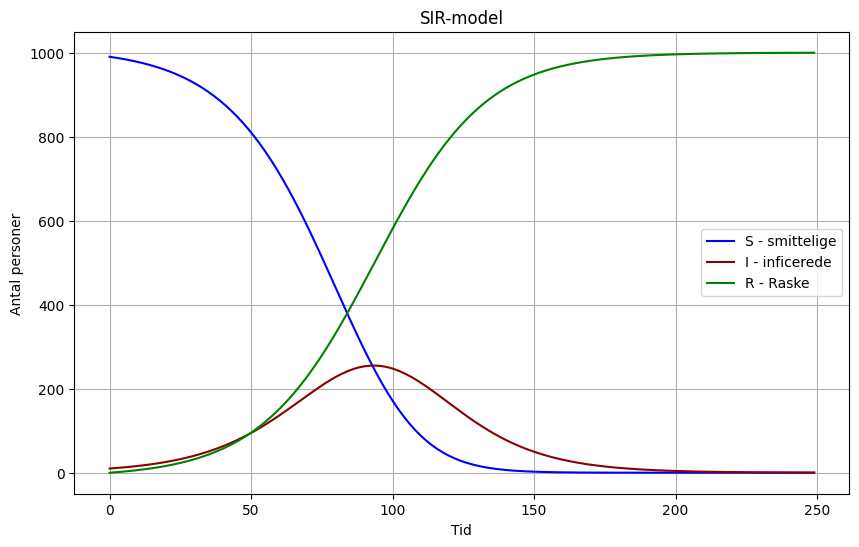

In [52]:
population = Population(S=990, I=10, R=0)
model = Model(smitteRate=0.1, raskRate=0.05)
simulering = Simulering(model, population)

historik = simulering.simuler(steps=250)
Plotter(historik).plot()